# LIBRARIES

In [42]:
import pandas as pd
import numpy as np

# Load CSV Files

In [43]:
train_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\train.csv")
val_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\val.csv")
test_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\test.csv")

In [44]:
train_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,1,0,0,0,0,0,1,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,3
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
val_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,55000,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,55001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
2,55002,0,0,0,0,0,0,0,0,0,...,176,195,144,0,0,0,0,0,0,0
3,55003,0,0,0,0,0,0,0,6,88,...,0,0,71,123,88,20,0,0,0,6
4,55004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [46]:
test_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat774,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783
0,0,0,0,0,0,0,0,1,1,2,...,2,0,0,60,36,24,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,123,97,0,0
2,2,0,0,0,0,0,0,0,0,0,...,2,1,0,0,115,150,47,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,144,0,0,0,0,0,0,0,0,0


In [47]:
print('train_df.shape:', train_df.shape, 
      'val_df.shape:', val_df.shape, 
      'test_df.shape:', test_df.shape)

train_df.shape: (55000, 786) val_df.shape: (5000, 786) test_df.shape: (10000, 785)


# Separate Labels And Features

In [48]:
# train.csv and val.csv contains labels

x_train = train_df.drop(["id", "label"], axis=1).values
y_train = train_df["label"].values

x_val = val_df.drop(["id", "label"], axis=1).values
y_val = val_df["label"].values

print("Fixed x_train shape:", x_train.shape)
print("Fixed x_val shape:", x_val.shape)

Fixed x_train shape: (55000, 784)
Fixed x_val shape: (5000, 784)


In [49]:
# test.csv does not contain labels

x_test = test_df.drop("id", axis=1).values

# Normalize pixel values
# Convert from 0-255 -> 0-1

In [50]:
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape 784 -> 28 * 28 * 1

In [51]:
x_train = x_train.reshape(-1,28,28,1)
x_val = x_val.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Visualizing Sample Training Images 
# Now that images are reshaped to 28×28,
# let's visualize some training examples.

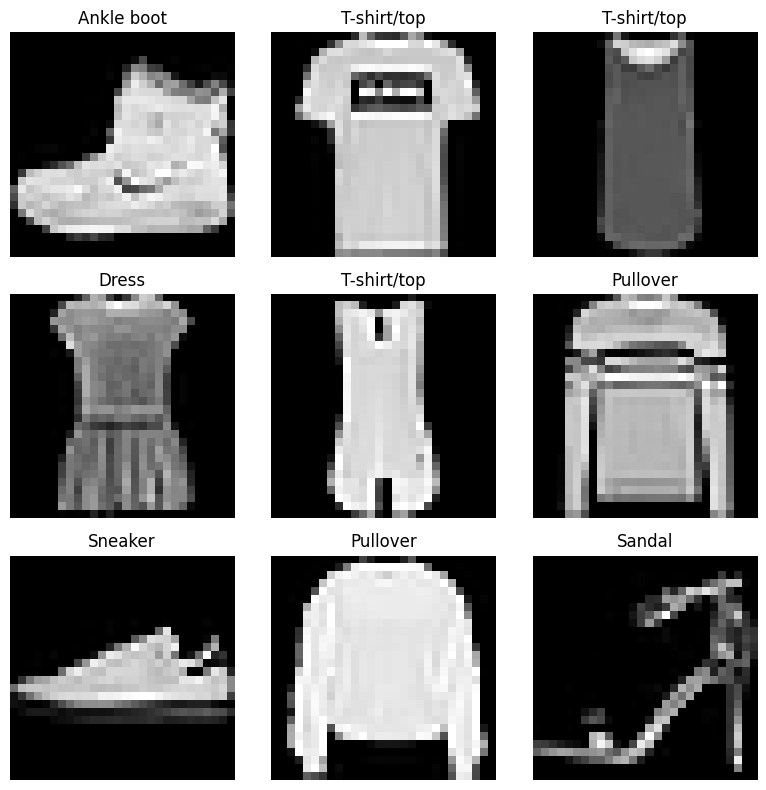

In [52]:
import matplotlib.pyplot as plt

# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    
    image = x_train[i].reshape(28,28)
    label = y_train[i]
    
    plt.imshow(image, cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Convert grayscale → RGB
# Required because CONV1 expects 3 channels

In [53]:
x_train = np.repeat(x_train,3,axis=-1)
x_val = np.repeat(x_val,3, axis=-1)
x_test = np.repeat(x_test,3,axis=-1)

print("Final x_train shape:", x_train.shape)

Final x_train shape: (55000, 28, 28, 3)


# Model Architecture

Now we implement the CNN architecture exactly as specified in the assignment:

- All convolution filters are 3×3
- Stride = 1
- Padding = 1 (same padding)
- ReLU activations
- Batch Normalization before Softmax
- Early stopping will be added during training

In [54]:
# BUILD CNN ARCHITECTURE (AS PER ASSIGNMENT)
import tensorflow as tf
from tensorflow.keras import layers ,models ,initializers

# Use He initialization (recommended for ReLU)
initializer = initializers.HeNormal()

model = models.Sequential()

In [55]:
# CONV1: 3 → 64
# Output: 64 × 28 × 28

model.add(layers.Conv2D(
    64, (3,3),
    strides=1,
    padding="same",
    activation="relu",
    kernel_initializer=initializer,
    input_shape=(28,28,3)
))

c:\python-envs\ml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
# POOL1 → 64 × 14 × 14

model.add(layers.MaxPooling2D((2,2)))

In [57]:
# CONV2: 64 → 128
# Output: 128 × 14 × 14

model.add(layers.Convolution2D(
          128, (3,3),
          strides=1,
          padding="same",
          activation="relu",
          kernel_initializer=initializer
))

In [58]:
# POOL2 → 128 × 7 × 7

model.add(layers.MaxPooling2D((2,2)))

In [59]:
# CONV3: 128 → 256
# Output: 256 × 7 × 7

model.add(layers.Convolution2D(
    256, (3,3),
    strides=1,
    padding="same",
    activation="relu",
    kernel_initializer=initializer
))

In [60]:
# CONV4: 256 → 256
# Output: 256 × 7 × 7

model.add(layers.Convolution2D(
    256, (3,3),
    strides=1,
    padding="same",
    activation="relu",
    kernel_initializer=initializer
))

In [61]:
# POOL3 → 256 × 3 × 3

model.add(layers.MaxPooling2D((2,2)))

In [62]:
# Flatten → 2304

model.add(layers.Flatten())

In [63]:
# FC1: 2304 → 1024

model.add(layers.Dense(
    1024, 
    activation="relu"
))

model.add(layers.Dropout(0.5)) # reduce overfitting

In [64]:
# FC2: 1024 → 1024

model.add(layers.Dense(
    1024,
    activation="relu"
))

model.add(layers.Dropout(0.5))

In [65]:
# BatchNorm before Softmax

model.add(layers.BatchNormalization())

In [66]:
# Softmax Layer: 1024 → 10

model.add(layers.Dense(
    10,
    activation="softmax"
))

In [67]:
# Show model summary

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,162 (16.73 MB)

 Trainable params: 4,383,114 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

# Training Details

The model is trained using:

- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 64
- Weight Initialization: He Normal
- Early Stopping: Patience = 5
- Loss Function: Sparse Categorical Crossentropy

We monitor validation loss to prevent overfitting.

In [68]:
# COMPILE AND TRAIN THE MODEL

# Import optimizer
import tensorflow as tf

In [69]:
# Learning rate
learning_rate = 0.001

In [70]:
# compile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [73]:
# Early stopping (Patience = 5 as required)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [74]:
# Train model

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 92s 102ms/step - accuracy: 0.7952 - loss: 0.5802 - val_accuracy: 0.8834 - val_loss: 0.3154
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.8904 - loss: 0.3049 - val_accuracy: 0.8994 - val_loss: 0.2746
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.9086 - loss: 0.2506 - val_accuracy: 0.9168 - val_loss: 0.2301
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.9208 - loss: 0.2209 - val_accuracy: 0.9216 - val_loss: 0.2178
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 84s 97ms/step - accuracy: 0.9258 - loss: 0.2018 - val_accuracy: 0.9178 - val_loss: 0.2315
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.9357 - loss: 0.1776 - val_accuracy: 0.9268 - val_loss: 0.2125
Epoch 7/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.9425 - loss: 0.1572 - val_accuracy: 0.9200 - val_loss: 0.2272
Epoch 8/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 84s 98ms/step - accuracy: 0.9513 - loss: 0.1347 -

# EXTRACT TRAINING INFORMATION FOR REPORT

In [77]:
# Total epochs actually trained
total_epochs_trained = len(history.history["loss"])

# Best validation accuracy
best_val_accuracy = max(history.history["val_accuracy"])

print("Total Epochs Trained:", total_epochs_trained)
print("Best Validation Accuracy:", best_val_accuracy)

Total Epochs Trained: 11
Best Validation Accuracy: 0.9279999732971191
